# Exercise 1

Create a model using K-Nearest Neigbors to perform classification using the personality dataset.

0 -'introvert'

1 - 'extrovert'

## A. Import libraries

In [27]:
import pandas as pd
import sklearn

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

## B. Load and understand the dataset

Display the first 5 rows of the dataset using `.head()`

In [28]:
df = pd.read_csv("personality_dataset.csv")
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,3,Yes,6,7,No,14,5,Extrovert
1,2,No,8,6,No,7,8,Extrovert
2,1,No,9,4,No,9,3,Extrovert
3,8,No,0,0,Yes,9,3,Introvert
4,5,Yes,3,0,No,2,6,Introvert


Display the summary of all the features of the dataset using `.info()`

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Time_spent_Alone           5000 non-null   int64 
 1   Stage_fear                 5000 non-null   object
 2   Social_event_attendance    5000 non-null   int64 
 3   Going_outside              5000 non-null   int64 
 4   Drained_after_socializing  5000 non-null   object
 5   Friends_circle_size        5000 non-null   int64 
 6   Post_frequency             5000 non-null   int64 
 7   Personality                5000 non-null   object
dtypes: int64(5), object(3)
memory usage: 312.6+ KB


Display the total number of samples from each label using `.value_counts()`

In [30]:
df["Stage_fear"] = df["Stage_fear"].astype(str).str.strip().map({"Yes":1, "No":0}).fillna(0).astype(int)
df["Drained_after_socializing"] = df["Drained_after_socializing"].astype(str).str.strip().map({"Yes":1, "No":0}).fillna(0).astype(int)
df["Personality"] = df["Personality"].astype(str).str.strip().map({"Introvert":0, "Extrovert":1})


df = df.dropna(subset=["Personality"])


df["Personality"] = df["Personality"].astype(int)

df["Personality"].value_counts()

,count
Personality,
0,2502
1,2498


Use a histogram to display the number of followers for each samples
 - The x axis should be the number of followers/friends
 - The y axis should be the number of samples in the dataset

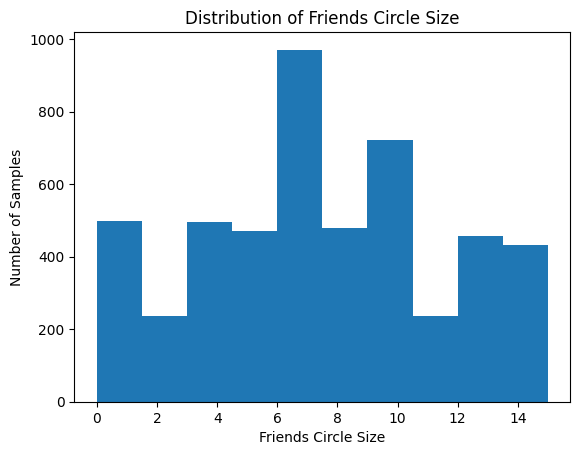

In [31]:
df = df.dropna()
plt.hist(df["Friends_circle_size"], bins=10)
plt.xlabel("Friends Circle Size")
plt.ylabel("Number of Samples")
plt.title("Distribution of Friends Circle Size")
plt.show()

Remove the name column using `drop()` method

In [32]:
# put your answer here

## C. Split the dataset into training and test set

Convert the features into an numpy array using `.values()` and store it in a variable "X"

In [33]:
X = df.drop("Personality", axis=1).values

Convert the labels into an numpy array using `.values()` and store it in a variable "y"

In [34]:
y = df["Personality"].values

Use `train_test_split()` to split the data.

- Declare a variable `X_train` that will hold the training data
- Declare a variable `X_test` that will hold the test data
- Declare a variable `y_train` that will hold the label of the training data
- Declare a variable `y_test` that will hold the label of the test data


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Display the dimensions of each variables using `.shape()`

In [36]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4000, 7)
(1000, 7)
(4000,)
(1000,)


## D. Create the model

Use KNN as a classifier by using `KNeighborsClassifier()`

In [37]:
knn = KNeighborsClassifier(n_neighbors=5)

Train the model using the `.fit()`

In [38]:

knn.fit(X_train, y_train)


KNeighborsClassifier()

Test the model using the `.predict()`

In [45]:
y_pred = knn.predict(X_test)

## E. Evaluate the model

Create a confusion matrix

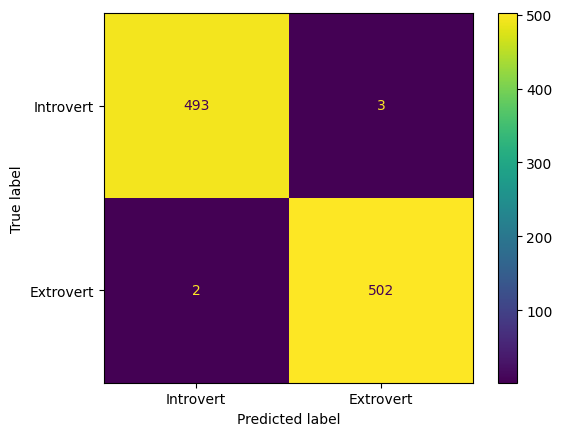

In [46]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Introvert", "Extrovert"]
)

disp.plot()
plt.show()

Display the accuracy

In [47]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.995


Display the precision

In [48]:
print("Precision:", precision_score(y_test, y_pred))

Precision: 0.994059405940594


Display the recall

In [49]:
print("Recall:", recall_score(y_test, y_pred))

Recall: 0.996031746031746


Display the f1-score

In [50]:
print("F1 Score:", f1_score(y_test, y_pred))

F1 Score: 0.9950445986124876


## F. Predict your own personality

Enter your own features and use the model to generate a prediction using `.predict()`

In [53]:
my_data = [[
    5,
    1,
    3,
    3,
    1,
    0,
    0
]]

prediction = knn.predict(my_data)

if prediction[0] == 0:
    print("Predicted Personality: Introvert")
else:
    print("Predicted Personality: Extrovert")

Predicted Personality: Introvert
